In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF, NeuMF
import pandas as pd
import numpy as np
import random
# import matha
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/yelp/indexed_interactions.csv",
    sep="\t",
    header=0,
    names=[ "itemID","Category", "userID","Rating", "Gender"],
)
rating_data = rating_data_pd[["userID", "itemID","Rating"]].to_numpy()
rating_data.__len__()
rating_data_pd


,itemID,Category,userID,Rating,Gender
0,0,Food & Restaurants|Drinks & Spirits,0,5,F
1,0,Food & Restaurants|Drinks & Spirits,1,4,F
2,0,Food & Restaurants|Drinks & Spirits,2,5,F
3,0,Food & Restaurants|Drinks & Spirits,3,3,M
4,0,Food & Restaurants|Drinks & Spirits,4,3,F
...,...,...,...,...,...
97986,1271,Food & Restaurants,1060,3,F
97987,1271,Food & Restaurants,161,2,M
97988,1271,Food & Restaurants,25,3,F
97989,1271,Food & Restaurants,280,4,F


In [3]:

restaurants = pd.read_csv("./cornac/data_c/yelp/i_id_mapping.csv",sep="\t",
    header=0,
    names=[ "item_id","Category","itemID"])
restaurants=restaurants.sort_values(by="itemID")

unique_categories = [
    "Active Life & Fitness",
    "Arts & Entertainment",
    "Automotive",
    "Bars & Nightlife",
    "Coffee,Tea & Desserts",
    "Drinks & Spirits",
    "Education & Learning",
    "Event Services",
    "Family & Kids",
    "Food & Restaurants",
    "Health & Beauty",
    "Home & Garden",
    "Miscellaneous",
    "Outdoor Activities",
    "Public Services & Community",
    "Shopping & Fashion",
    "Specialty Food & Groceries",
    "Sports & Recreation",
    "Technology & Electronics",
    "Travel & Transportation",
    "Asian",
]
for c in unique_categories:
    restaurants[c] = 0
for index, row in restaurants.iterrows():
    cats = row["Category"].split("|")
    for cat in cats:
        restaurants.at[index, cat] = 1

cat = restaurants[unique_categories]
# cat[:1]
item_features_numpy = cat.to_numpy()
item_features = {
    str(item_id): {"category_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
# ids = list(range(0, 3416))

In [4]:
restaurants

,item_id,Category,itemID,Active Life & Fitness,Arts & Entertainment,Automotive,Bars & Nightlife,"Coffee,Tea & Desserts",Drinks & Spirits,Education & Learning,...,Home & Garden,Miscellaneous,Outdoor Activities,Public Services & Community,Shopping & Fashion,Specialty Food & Groceries,Sports & Recreation,Technology & Electronics,Travel & Transportation,Asian
0,34,Food & Restaurants|Drinks & Spirits,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,250,Food & Restaurants|Drinks & Spirits,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,759,Asian|Food & Restaurants,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1085,Food & Restaurants,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1122,Travel & Transportation,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,188255,Food & Restaurants,1267,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1268,188310,Food & Restaurants,1268,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1269,188449,Food & Restaurants|Bars & Nightlife,1269,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1270,188454,Food & Restaurants,1270,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:

users = pd.read_csv("./cornac/data_c/yelp/u_id_mapping.csv", sep="\t",header=0,
    names=[ "user_id","Gender","userID"])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
users = users.sort_values(by="userID")
users = users[["Gender", "userID"]]

user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
# print(item_features_numpy.shape)

(1316, 2)


In [6]:
# users
user_features_numpy[:,0]

array([1, 1, 1, ..., 1, 0, 0])

In [7]:
# users
item_features_numpy

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [8]:
dataset = rating_data
unique_categories.__len__()

21

In [9]:
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()
f1 = cornac.metrics.FMeasure(k=50)
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0,
    val_size=0.1,
    seed=123,
    verbose=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,fmt="UIR"
)
models = []
model_1 = UserKNN(k=20, seed=123, verbose=True)
model_2 = ItemKNN(k=20, seed=123, verbose=True)
model_3 =MF(
            k=20,
            seed=123,
            name=f"a={3} mf",
            backend="pytorch",
            verbose=True,
            optimizer="adam",batch_size=128,
            alpha=0.3,
            learning_rate=0.001,
            top_k=50, max_iter=15,run_mode="bce",
            # early_stopping=True
        )
model_4 = VAECF(
            k=20,
            autoencoder_structure=[60,32],
            act_fn="relu",
            likelihood="bern",
            n_epochs=50,
            batch_size=128,
            learning_rate=0.0005,
            alpha=0.3,
            top_k=50,
            beta=1,
            name=f"a={3} vae",
            seed=123,
            verbose=True,
            # early_stopping=True
        )
model_5 = NeuMF(num_factors=8,seed=123, layers=[32,16,8], act_fn="sigmoid", num_epochs=51, batch_size=256, num_neg=3, backend="pytorch", lr=0.001, alp=0.4, top_k=50, name=str(4)+ "neumf")
 
# models.append(model_1)
# models.append(model_2)
models.append(model_3)
models.append(model_4)
models.append(model_5)
cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, prec, hr, mrr, map, f1]
).run()


rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([   0,    0,    0, ..., 1315, 1315, 1315]), array([   0,    1,    2, ..., 1030,  793, 1250]), array([4., 5., 2., ..., 4., 5., 5.]))
Number of users = 1316
Number of items = 1272
Number of ratings = 67470
Max rating = 5.0
Min rating = 1.0
Global mean = 3.9
Global mean Imolicit= 1.0
::::::::
OrderedDict([(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 11), (12, 12), (13, 13), (14, 14), (15, 15), (16, 16), (17, 17), (18, 18), (19, 19), (20, 20), (21, 21), (22, 22), (23, 23), (24, 24), (25, 25), (26, 26), (27, 27), (28, 28), (29, 29), (30, 30), (31, 31), (32, 32), (33, 33), (34, 34), (35, 35), (36, 36), (37, 37), (38, 38), (39, 39), (40, 40), (41, 41), (42, 42), (43, 43), (44, 44), (45, 45), (46, 46), (47, 47), (48, 48), (49, 49), (50, 50), (51, 51), (52, 52), (53, 53), (54, 54), (55, 55), (56, 56), (57, 57), (58, 58), (59, 5

100%|██████████| 15/15 [02:06<00:00,  8.41s/it, loss=0.589]


[75.1856918334961, 75.14213562011719, 75.1289291381836, 75.12618255615234, 75.12811279296875, 75.15062713623047, 75.13076782226562, 75.171142578125, 75.18346405029297, 75.14305114746094, 75.17152404785156, 75.19615936279297, 75.162109375, 75.15966796875, 75.19003295898438, 75.17061614990234, 75.20176696777344, 75.18743896484375, 75.21517944335938, 75.16839599609375, 75.24760437011719, 75.14763641357422, 75.2013931274414, 75.15161895751953, 75.24959564208984, 75.18900299072266, 75.17430114746094, 75.22987365722656, 75.20999145507812, 75.24018859863281, 75.16230010986328, 75.24175262451172, 75.17720031738281, 75.1894760131836, 75.19290161132812, 75.23490142822266, 75.26118469238281, 75.22486877441406, 75.33077239990234, 75.13883972167969, 75.10345458984375, 75.17413330078125, 75.11699676513672, 75.16805267333984, 75.19942474365234, 75.19368743896484, 75.32427215576172, 75.12471771240234, 75.24671936035156, 75.16338348388672, 75.27862548828125, 75.1702651977539, 75.18464660644531, 75.2340

Ranking: 100%|██████████| 1316/1316 [00:00<00:00, 2208.67it/s]



[a=3 vae] Training started!


...


[4neumf] Training started!


100%|██████████| 51/51 [19:06<00:00, 22.49s/it, loss=0.543]


[0.5449297428131104, 0.5450064539909363, 0.5448033809661865, 0.5446662902832031, 0.5446685552597046, 0.5446296334266663, 0.544582724571228, 0.5445103645324707, 0.5444818735122681, 0.5444246530532837, 0.5443458557128906, 0.5443288087844849, 0.5443165898323059, 0.544273853302002, 0.5442199110984802, 0.5442160367965698, 0.544196605682373, 0.5441527366638184, 0.5442702174186707, 0.5441637635231018, 0.5441822409629822, 0.5441751480102539, 0.5442720651626587, 0.5443146228790283, 0.5444270968437195, 0.5441877841949463, 0.5442071557044983, 0.5443523526191711, 0.5444599390029907, 0.5442512035369873, 0.5441915988922119, 0.5441842079162598, 0.5441358685493469, 0.5441473722457886, 0.5441445112228394, 0.5442618727684021, 0.5441656112670898, 0.5442752242088318, 0.5442553758621216, 0.5443950891494751, 0.5442773103713989, 0.5441392064094543, 0.544145405292511, 0.5441309809684753, 0.544124186038971, 0.5441333055496216, 0.5441206693649292, 0.5441308617591858, 0.5441306829452515, 0.5441173315048218, 0.54

Ranking: 100%|██████████| 1316/1316 [00:01<00:00, 1206.91it/s]


VALIDATION:
...
        |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Time (s)
------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------
a=3 mf  | 0.6376 | 0.0308 |      0.5691 | 0.0303 | 0.1065 |  0.0679 |       0.0186 |    0.1171 |   0.5976
a=3 vae | 0.6280 | 0.0335 |      0.6049 | 0.0316 | 0.1119 |  0.0741 |       0.0202 |    0.1278 |   0.7643
4neumf  | 0.5924 | 0.0355 |      0.6140 | 0.0315 | 0.1169 |  0.0779 |       0.0215 |    0.1348 |   1.0921

TEST:
...
        |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=3 mf  | 0.6385 | 0.0532 |      0.7903 | 0.0401 | 0.1565 |  0.0856 |       0.0370 |    0.1212 |  126.7841 |   0.7936
a=3 vae | 0.6289 | 0.0566 |      0.7986 | 0.0437 | 0.1839 |  0.0959 |       0.0389 |    

In [10]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
print(len(user_ids))
print(len(item_ids))
print(user_ids)
print(item_ids)

1316
1272
[   0    1    2 ... 1313 1314 1315]
[0 1 2 ... 1269 1270 1271]


In [17]:
# models[0].save("./saved")
import pickle

with open('mf100kyelp.pkl', 'wb') as f:
    # Pickle the 'data' dictionary using the highest protocol available.
    pickle.dump(models, f, pickle.HIGHEST_PROTOCOL)


In [27]:
reco_matrix_old = reco_matrix
reco_matrix_all_old = reco_matrix_all

In [11]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
item_ids.__len__()
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [12]:
# new_reco_matrix = np.zeros((5, len(user_ids), top_k), dtype=int)
# new_reco_matrix_all = np.zeros((5, len(user_ids), len(item_ids)), dtype=int)
# new_reco_matrix[0] = reco_matrix_old[0] #iknn
# new_reco_matrix[1] = reco_matrix_old[1] #userknn
# new_reco_matrix[2] = reco_matrix[0] #mf
# new_reco_matrix[3] = reco_matrix_old[3] #vaecf
# new_reco_matrix[4] = reco_matrix_old[4] #neumf

# new_reco_matrix_all[0] = reco_matrix_all_old[0] #iknn
# new_reco_matrix_all[1] = reco_matrix_all_old[1] #userknn
# new_reco_matrix_all[2] = reco_matrix_all[0] #mf
# new_reco_matrix_all[3] = reco_matrix_all_old[3] #vaecf
# new_reco_matrix_all[4] = reco_matrix_all_old[4] #neumf
new_reco_matrix_all = reco_matrix_all
new_reco_matrix = reco_matrix

In [13]:
np.save("reco_matrix_uknn_iknn.npy", reco_matrix)
# np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
# np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all_uknn_iknn.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [13]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMapEdited import GenreMapEdited
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision


top_k = 50
###intialize them
gp = GenrePrecision(users, unique_categories, top_k)
gr = GenreRecall(users, unique_categories, top_k)
gm = GenreMapEdited(users, unique_categories, top_k)
gndcg = GenreNDCG(users, unique_categories, top_k)
gmrr = GenreMRR(users, unique_categories, top_k)

In [14]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(new_reco_matrix)):
    ####Precision####
    model_gps.append(gp.compute(new_reco_matrix[i], restaurants))
    model_grs.append(gr.compute(new_reco_matrix[i], restaurants))
    model_gms.append(gm.compute(new_reco_matrix[i], restaurants))
    model_gdcgs.append(gndcg.compute(new_reco_matrix[i], restaurants))
    model_gmrrs.append(gmrr.compute(new_reco_matrix[i], restaurants))


restaurants = restaurants.rename(columns={"Category": "genres"})
# ####IR Metrics####
# ####Rprecision####
model_grps = []
# for i in range(len(models)):
#     model_grps.append(grp.compute(reco_matrix_top_r[i], restaurants_df, restaurants))


In [15]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = restaurants[unique_categories].div(restaurants[unique_categories].sum(axis=1), axis=0)
movies_df = movies_df[unique_categories].sum()
import math
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(new_reco_matrix), len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(len(new_reco_matrix)):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = new_reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_categories, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [20]:
model_grps = []
for i in range(len(new_reco_matrix)):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, restaurants))

        Active Life & Fitness  Arts & Entertainment  Automotive  \
Gender                                                            
0                    0.000049              0.058608         0.0   
1                    0.000019              0.055639         0.0   

        Bars & Nightlife  Coffee,Tea & Desserts  Drinks & Spirits  \
Gender                                                              
0               0.097638               0.080077          0.000071   
1               0.095917               0.082231          0.000037   

        Education & Learning  Event Services  Family & Kids  \
Gender                                                        
0                        0.0        0.029640            0.0   
1                        0.0        0.028693            0.0   

        Food & Restaurants  ...  Home & Garden  Miscellaneous  \
Gender                      ...                                 
0                 0.532752  ...            0.0            0.0   
1     

In [21]:
model_grps.__len__()

3

In [22]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(reco_matrix))]
gr_sum = [sum(abs(model_grs[i])) for i in range(len(reco_matrix))]
gm_sum = [sum(abs(model_gms[i])) for i in range(len(reco_matrix))]
gdcg_sum = [sum(abs(model_gdcgs[i])) for i in range(len(reco_matrix))]
gmrr_sum = [sum(abs(model_gmrrs[i])) for i in range(len(reco_matrix))]
grp_sum = [sum(abs(model_grps[i])) for i in range(len(reco_matrix))]


In [23]:
from operator import itemgetter

# unique_genres
indices = [4, 1, 19, 20]

compare_genres = itemgetter(*indices)(unique_categories)
# compare_genres = unique_genres
# indices = range(18)
# alpha_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99999999999]

list(compare_genres)

['Coffee,Tea & Desserts',
 'Arts & Entertainment',
 'Travel & Transportation',
 'Asian']

In [80]:
compare_genres = ['Coffee,Tea & \nDesserts',
 'Arts &\n Entertainment',
 'Travel & \nTransportation',
 'Asian']

['MF', 'MF_gr', 'MF_gp', 'VAECF', 'VAECF_gr', 'VAECF_gp', 'NeuMF', 'NeuMF_gr', 'NeuMF_gp']
[<BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>]


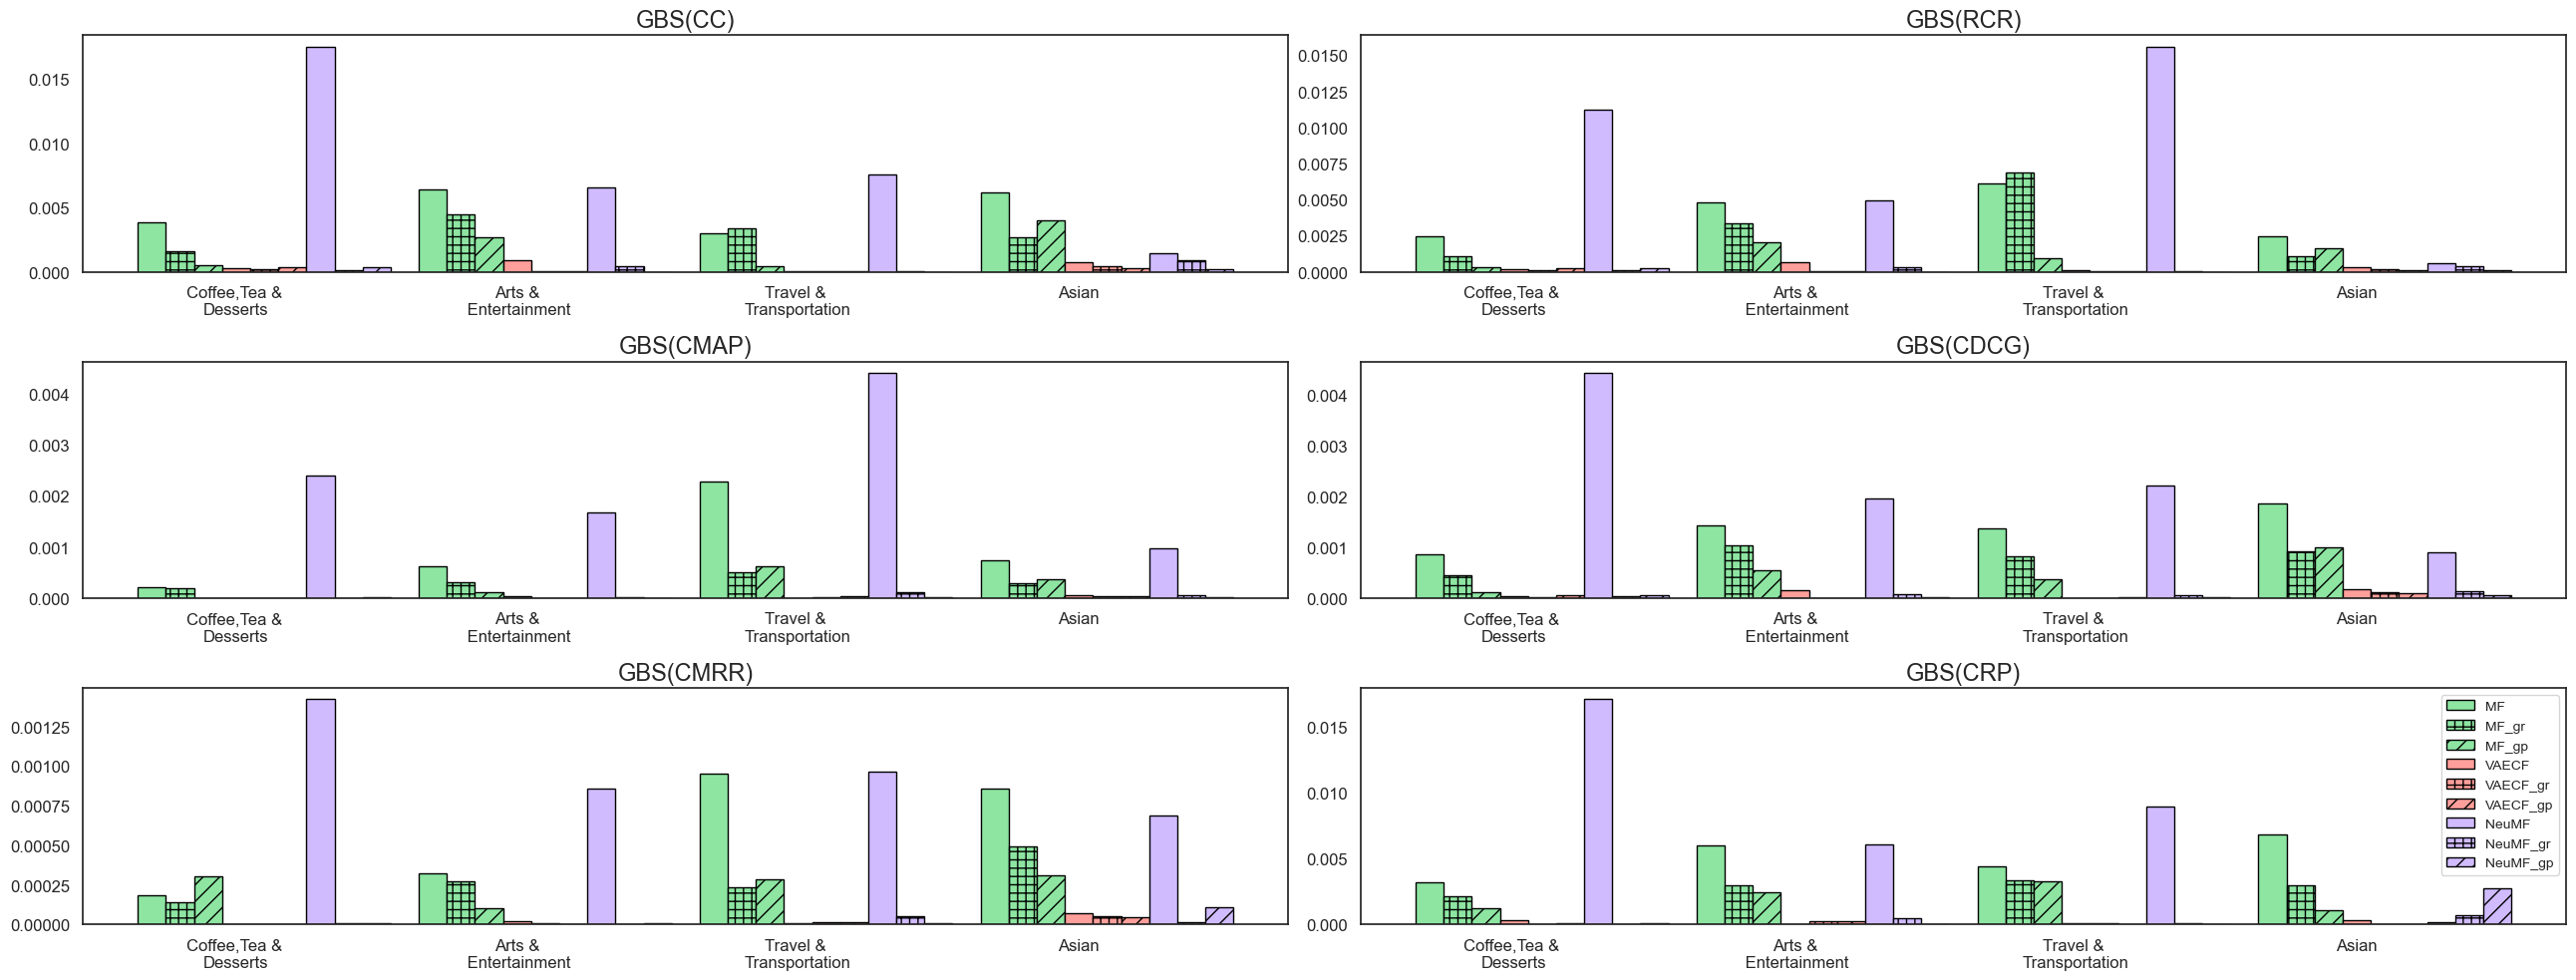

In [65]:
import matplotlib.pyplot as plt
import numpy as np
sns.set(style="white")
pastel_colors = sns.color_palette("pastel")

# alpha_values =[0,0.1,0.2,0.3,0.4,0.5,0.6]
matrices_mfreg = [
 model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
matrices_mfreg_gp = np.array([[-5.29582289e-04,  2.70232225e-03,  4.70087437e-04,
        -4.01063923e-03],
       [-3.40015533e-04,  2.02312896e-03,  9.65555181e-04,
        -1.60446962e-03],
       [-2.21232237e-06,  1.18432068e-04,  6.26177461e-04,
        -3.70040838e-04],
       [ 1.09968446e-04,  5.50222305e-04,  3.72365157e-04,
        -9.93396438e-04],
       [ 3.06178941e-04,  9.97763036e-05,  2.86775605e-04,
        -3.12211527e-04],
       [-1.25982524e-03,  2.44944583e-03,  3.30358821e-03,
        -1.10487416e-03]])
 
matrices_mf0= [
   yelp_dataset[2][0],
    yelp_dataset[2][1],
   yelp_dataset[2][2],
    yelp_dataset[2][3],
    yelp_dataset[2][4],
    yelp_dataset[2][5],
]
matrices_vae0 = [
    yelp_dataset[3][0],
    yelp_dataset[3][1],
   yelp_dataset[3][2],
    yelp_dataset[3][3],
    yelp_dataset[3][4],
    yelp_dataset[3][5],
]
matrices_vaereg_gp = np.array([[ 3.58731620e-04, -3.13369711e-05, -3.35283676e-05,
        -3.00659610e-04],
       [ 2.30321757e-04, -2.34608339e-05, -6.88669523e-05,
        -1.20279881e-04],
       [ 8.75775430e-06,  5.44666600e-06, -3.40039578e-05,
        -3.21748915e-05],
       [ 5.01510660e-05,  5.70947320e-07, -1.76887192e-05,
        -8.96097295e-05],
       [-3.24942162e-06,  3.58891122e-06, -1.71728370e-05,
        -4.71787985e-05],
       [ 1.33521898e-04,  2.13977571e-04,  4.00598611e-05,
         9.64343073e-06]])
matrices_vaereg = [
    model_gps[1][indices],
    model_grs[1][indices],
    model_gms[1][indices],
    model_gdcgs[1][indices],
    model_gmrrs[1][indices],
    model_grps[1][indices],
]
matrices_neumf0 = [
    yelp_dataset[4][0],
    yelp_dataset[4][1],
   yelp_dataset[4][2],
    yelp_dataset[4][3],
    yelp_dataset[4][4],
    yelp_dataset[4][5],
]
matrices_neureg = [
    model_gps[2][indices],
    model_grs[2][indices],
    model_gms[2][indices],
    model_gdcgs[2][indices],
    model_gmrrs[2][indices],
    model_grps[2][indices],
]
matrices_neureg_gp = np.array([[-3.49966033e-04,  0.00000000e+00,  0.00000000e+00,
         2.29329652e-04],
       [-2.24693858e-04,  0.00000000e+00,  0.00000000e+00,
         9.17440933e-05],
       [-1.30449135e-05,  5.62015384e-06,  2.39310486e-05,
        -2.27949552e-05],
       [-5.98582767e-05,  1.32848467e-05,  1.02320573e-05,
        -5.90606868e-05],
       [-5.31413045e-06,  1.04163688e-05,  9.49173970e-06,
        -1.11304584e-04],
       [-9.24382370e-05, -3.39197722e-05,  0.00000000e+00,
        -2.72543078e-03]])
labels = compare_genres
titles = [
    "GBS(CC)",
    "GBS(RCR)",
    "GBS(CMAP)",
    "GBS(CDCG)",
    "GBS(CMRR)",
    "GBS(CRP)",
]


fig, axs = plt.subplots(3,2, figsize=(26, 10))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.1  # the width of the bars
bar_spacing =0.0
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
hatches = ['//', '\\\\', '||', '--', '++']

for i in range(len(titles)):
    axs[i].bar(
        x - 3 * (bar_width + bar_spacing), abs(matrices_mf0[i]), bar_width, color=pastel_colors[2],
        edgecolor='black', label="MF"
    )
    axs[i].bar(
        x - 2 * (bar_width + bar_spacing), abs(matrices_mfreg[i]), bar_width, color=pastel_colors[2],
        edgecolor='black', label="MF_gr", hatch=hatches[-1]
    )
    axs[i].bar(
        x - 1 * (bar_width + bar_spacing), abs(matrices_mfreg_gp[i]), bar_width, color=pastel_colors[2],
        edgecolor='black', label="MF_gp", hatch=hatches[0]
    )
    axs[i].bar(
        x + 0 * (bar_width + bar_spacing), abs(matrices_vae0[i]), bar_width, color=pastel_colors[3],
        edgecolor='black',  label="VAECF"
    )
    axs[i].bar(
        x +1 * (bar_width + bar_spacing), abs(matrices_vaereg[i]), bar_width, color=pastel_colors[3],
        edgecolor='black', label="VAECF_gr", hatch=hatches[-1]
    )
    axs[i].bar(
        x + 2* (bar_width + bar_spacing), abs(matrices_vaereg_gp[i]), bar_width, color=pastel_colors[3],
        edgecolor='black', label="VAECF_gp", hatch=hatches[0]
    )
    axs[i].bar(
        x + 3 * (bar_width + bar_spacing), abs(matrices_neumf0[i]), bar_width, color=pastel_colors[4],
        edgecolor='black', label="NeuMF"
    )
    
    axs[i].bar(
        x + 4 * (bar_width + bar_spacing), abs(matrices_neureg[i]), bar_width, color=pastel_colors[4],
        edgecolor='black', label="NeuMF_gr", hatch=hatches[-1]
    )
    axs[i].bar(
        x +5 * (bar_width + bar_spacing), abs(matrices_neureg_gp[i]), bar_width, color=pastel_colors[4],
        edgecolor='black', label="NeuMF_gp", hatch=hatches[0]
    )
    
    axs[i].set_xticks(x)
    # axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=17)
    # axs[i].set_yticklabels( fontsize=17)
    # axs[i].tick_params(axis="y", labelsize =12)
    axs[i].set_xticklabels(compare_genres, rotation=0, fontsize=12)
    axs[i].tick_params(axis="y", labelsize=12)
    # axs[i].set_y
    axs[i].set_title(titles[i], fontsize =17)
    # axs[i].set_xlabel("Genres")
    # axs[i].set_ylabel("Values")
    
    


handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)


plt.legend(handles, labels, loc="upper right", fontsize="small")
# Adjust layout
plt.tight_layout()
plt.savefig("all_models_reg_yelp.pdf", format="pdf")

plt.show()

In [27]:
yelp_dataset = [[np.array([-0.00156712,  0.00055592,  0.00052878, -0.00027414]),
  np.array([-0.00100616,  0.0004162 ,  0.00108612, -0.00010967]),
  np.array([-5.50794160e-04, -5.98549115e-06,  2.44820711e-05, -1.62735764e-05]),
  np.array([-6.64189693e-04,  5.68491492e-05,  1.13618072e-04, -4.95461145e-05]),
  np.array([-4.54476414e-04, -2.62780288e-05,  2.49411191e-05, -3.70757164e-06]),
  np.array([-0.00133214,  0.0004787 ,  0.00019217, -0.00048771])],
 [np.array([-0.00385812,  0.00436408,  0.00261333, -0.00358618]),
  np.array([-0.00247709,  0.00326723,  0.00536776, -0.00143466]),
  np.array([-0.00066944,  0.00046471,  0.00071573, -0.00031911]),
  np.array([-0.0015569 ,  0.00096918,  0.00071816, -0.00102287]),
  np.array([-0.00095674,  0.00024312,  0.00027029, -0.00044144]),
  np.array([-0.00241846,  0.00445874,  0.00278678, -0.00262425])],
 [np.array([-0.0038676 ,  0.00643957,  0.00299338, -0.00619502]),
  np.array([-0.00248317,  0.00482107,  0.00614838, -0.00247834]),
  np.array([-0.0002186 ,  0.00062414,  0.00227256, -0.00073245]),
  np.array([-0.00086291,  0.00142396,  0.00137575, -0.00186547]),
  np.array([-0.00018339,  0.00032012,  0.00095121, -0.00085695]),
  np.array([-0.00317718,  0.00599657,  0.00437935, -0.00681786])],
 [np.array([ 2.74581991e-04,  8.71518419e-04,  6.28930818e-05, -7.18011088e-04]),
  np.array([ 0.00017629,  0.00065247,  0.00012918, -0.00028724]),
  np.array([ 4.05077117e-06,  4.44646477e-05, -8.98419175e-06, -5.25353937e-05]),
  np.array([ 4.35939841e-05,  1.57210698e-04,  4.90940931e-06, -1.81751790e-04]),
  np.array([ 2.07610246e-06,  1.97550099e-05, -5.36147162e-06, -7.22334714e-05]),
  np.array([ 3.35352417e-04, -2.28456023e-05,  7.87693899e-05,  3.45432072e-04])],
 [np.array([-0.01753799,  0.0065905 ,  0.00760006,  0.0014778 ]),
  np.array([-0.01126017,  0.00493406,  0.01561046,  0.0005912 ]),
  np.array([-0.00239883,  0.00166945,  0.00440227,  0.00097577]),
  np.array([-0.00443248,  0.00195941,  0.00222244,  0.00089704]),
  np.array([-0.00142186,  0.00085539,  0.00096256,  0.00068927]),
  np.array([-0.01706546,  0.00606464,  0.00896292, -0.00014307])]]

6

In [ ]:
np.abs(matrices_mf0)

array([[0.0038676 , 0.00643957, 0.00299338, 0.00619502],
       [0.00248317, 0.00482107, 0.00614838, 0.00247834],
       [0.0002186 , 0.00062414, 0.00227256, 0.00073245],
       [0.00086291, 0.00142396, 0.00137575, 0.00186547],
       [0.00018339, 0.00032012, 0.00095121, 0.00085695],
       [0.00317718, 0.00599657, 0.00437935, 0.00681786]])

In [77]:
matrices_mf0

[array([-0.0038676 ,  0.00643957,  0.00299338, -0.00619502]),
 array([-0.00248317,  0.00482107,  0.00614838, -0.00247834]),
 array([-0.0002186 ,  0.00062414,  0.00227256, -0.00073245]),
 array([-0.00086291,  0.00142396,  0.00137575, -0.00186547]),
 array([-0.00018339,  0.00032012,  0.00095121, -0.00085695]),
 array([-0.00317718,  0.00599657,  0.00437935, -0.00681786])]

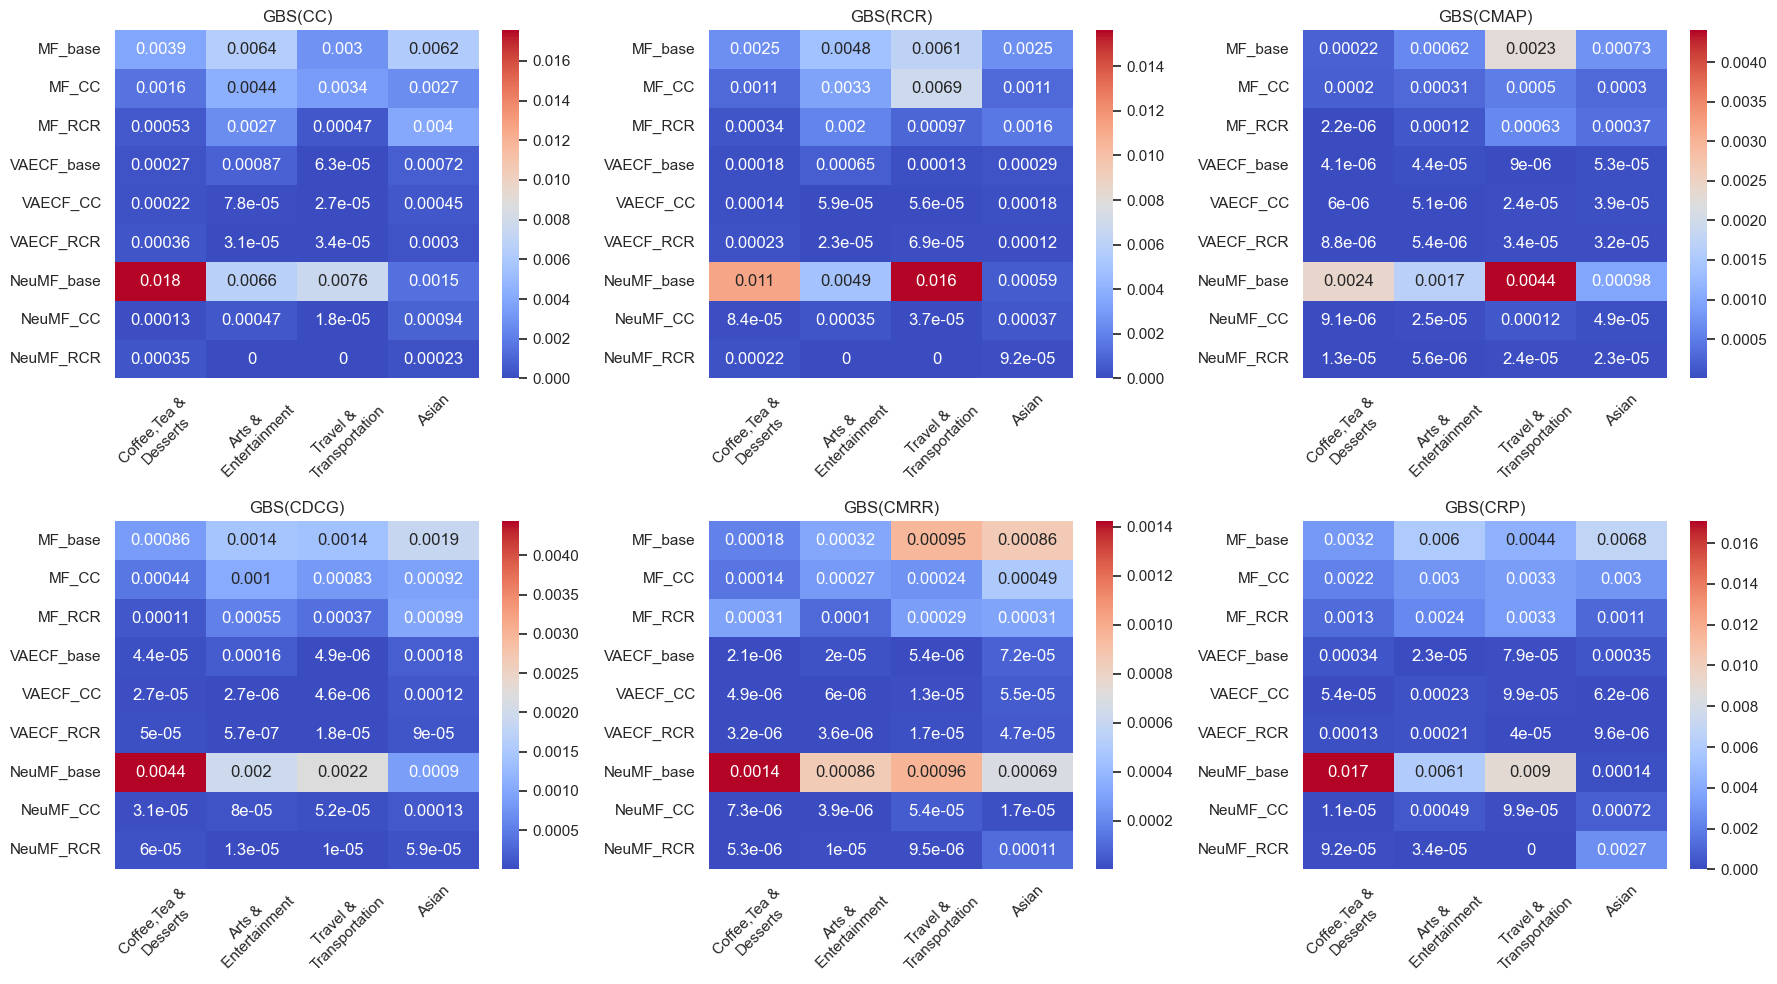

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set(style="white")
pastel_colors = sns.color_palette("pastel")
compare_genres =compare_genres
titles = ["GBS(CC)", "GBS(RCR)", "GBS(CMAP)", "GBS(CDCG)", "GBS(CMRR)", "GBS(CRP)"]

# Example data (replace with your real arrays)
# Shape: 6 titles × 4 genres per variant
# Each is 6x4 numpy array
MF_base = np.abs(matrices_mf0)
MF_gr   = np.abs(matrices_mfreg)
MF_gp   =np.abs(matrices_mfreg_gp)
VAECF_base = np.abs(matrices_vae0)
VAECF_gr   = np.abs(matrices_vaereg)
VAECF_gp   =np.abs(matrices_vaereg_gp)
NeuMF_base = np.abs(matrices_neumf0)
NeuMF_gr   = np.abs(matrices_neureg)
NeuMF_gp   = np.abs(matrices_neureg_gp)



# --- Option 4: Heatmaps (one per subplot)
fig, axs = plt.subplots(2,3, figsize=(18,10))
axs = axs.flatten()

for i in range(6):
    data = np.vstack([
        MF_base[i], MF_gr[i], MF_gp[i],
        VAECF_base[i], VAECF_gr[i], VAECF_gp[i],
        NeuMF_base[i], NeuMF_gr[i], NeuMF_gp[i]
    ])
    sns.heatmap(data, ax=axs[i], annot=True, cbar=True, cmap="coolwarm")
    axs[i].set_title(titles[i])
    axs[i].set_yticklabels(['MF_base','MF_CC','MF_RCR','VAECF_base','VAECF_CC','VAECF_RCR','NeuMF_base','NeuMF_CC','NeuMF_RCR'], rotation=0)
    axs[i].set_xticklabels(compare_genres, rotation=45)

plt.tight_layout()
plt.show()


In [71]:
matrices_mf0

[array([-0.0038676 ,  0.00643957,  0.00299338, -0.00619502]),
 array([-0.00248317,  0.00482107,  0.00614838, -0.00247834]),
 array([-0.0002186 ,  0.00062414,  0.00227256, -0.00073245]),
 array([-0.00086291,  0.00142396,  0.00137575, -0.00186547]),
 array([-0.00018339,  0.00032012,  0.00095121, -0.00085695]),
 array([-0.00317718,  0.00599657,  0.00437935, -0.00681786])]